In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Thiết lập hiển thị bảng pandas đẹp mắt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Khai báo 5 câu giao dịch
corpus = {
    "s1": "The user bought a wireless mouse and a mechanical keyboard.",
    "s2": "The user bought a gaming laptop and a wireless mouse.",
    "s3": "The user bought noise-canceling headphones and a smart watch.",
    "s4": "The user bought a mechanical keyboard and an ergonomic chair.",
    "s5": "The user bought a smart watch and a wireless charger."
}

df_corpus = pd.DataFrame(list(corpus.items()), columns=["Sentence_ID", "Raw_Text"])
df_corpus

,Sentence_ID,Raw_Text
0,s1,The user bought a wireless mouse and a mechani...
1,s2,The user bought a gaming laptop and a wireless...
2,s3,The user bought noise-canceling headphones and...
3,s4,The user bought a mechanical keyboard and an e...
4,s5,The user bought a smart watch and a wireless c...


---
### 2. Cơ sở Toán học của Biểu diễn TF-IDF

Cho tập ngữ liệu $D = \{s_1, s_2, \dots, s_N\}$ với $N = 5$ văn bản và tập từ vựng $V = \{t_1, t_2, \dots, t_d\}$ kích thước $d$:

#### 2.1. Tần suất từ (Term Frequency - TF)
Đo lường mức độ xuất hiện của từ $t$ trong câu $d$:
$$\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$$
*(hoặc tần số xuất hiện thô $f_{t,d}$)*

#### 2.2. Nghịch đảo tần suất văn bản (Inverse Document Frequency - IDF)
Đo lường độ hiếm và tính phân biệt của từ $t$ trên toàn bộ $N$ văn bản (theo chuẩn làm mượt của Scikit-Learn):
$$\text{IDF}(t, D) = \ln\left(\frac{1 + N}{1 + \text{DF}(t)}\right) + 1$$
trong đó $\text{DF}(t)$ là số lượng văn bản chứa từ $t$.

#### 2.3. Trọng số TF-IDF & Chuẩn hóa $L_2$
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$
Vector sau đó được chuẩn hóa theo chuẩn Euclid ($L_2$ norm) để có độ dài đơn vị $\|\mathbf{x}_i\|_2 = 1$:
$$\mathbf{x}_i = \frac{\mathbf{v}_i}{\sqrt{\sum_{j=1}^d v_{ij}^2}} \in \mathbb{R}^d$$

In [2]:
# Khởi tạo TfidfVectorizer
# Giữ toàn bộ từ vựng (kể cả stopwords) để thấy rõ tác dụng giảm trọng số của IDF đối với từ phổ biến
vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r'(?u)\b\w+\b',
    norm='l2',
    smooth_idf=True
)

# Khớp và chuyển đổi ma trận TF-IDF
tfidf_matrix = vectorizer.fit_transform(df_corpus["Raw_Text"])
feature_names = vectorizer.get_feature_names_out()

print(f"Tổng số câu (N): {tfidf_matrix.shape[0]}")
print(f"Kích thước Không gian đặc trưng / Từ vựng (d): {tfidf_matrix.shape[1]}")
print(f"Dạng ma trận đặc trưng: X in R^({tfidf_matrix.shape[0]} x {tfidf_matrix.shape[1]})\n")
print("Danh sách các từ vựng (Vocabulary):")
for idx, word in enumerate(feature_names):
    idf_val = vectorizer.idf_[idx]
    df_count = sum(1 for text in corpus.values() if word in text.lower())
    print(f" [{idx:2d}] {word:16s} | DF = {df_count}/5 | IDF = {idf_val:.4f}")

Tổng số câu (N): 5
Kích thước Không gian đặc trưng / Từ vựng (d): 20
Dạng ma trận đặc trưng: X in R^(5 x 20)

Danh sách các từ vựng (Vocabulary):
 [ 0] a                | DF = 5/5 | IDF = 1.0000
 [ 1] an               | DF = 5/5 | IDF = 2.0986
 [ 2] and              | DF = 5/5 | IDF = 1.0000
 [ 3] bought           | DF = 5/5 | IDF = 1.0000
 [ 4] canceling        | DF = 1/5 | IDF = 2.0986
 [ 5] chair            | DF = 1/5 | IDF = 2.0986
 [ 6] charger          | DF = 1/5 | IDF = 2.0986
 [ 7] ergonomic        | DF = 1/5 | IDF = 2.0986
 [ 8] gaming           | DF = 1/5 | IDF = 2.0986
 [ 9] headphones       | DF = 1/5 | IDF = 2.0986
 [10] keyboard         | DF = 2/5 | IDF = 1.6931
 [11] laptop           | DF = 1/5 | IDF = 2.0986
 [12] mechanical       | DF = 2/5 | IDF = 1.6931
 [13] mouse            | DF = 2/5 | IDF = 1.6931
 [14] noise            | DF = 1/5 | IDF = 2.0986
 [15] smart            | DF = 2/5 | IDF = 1.6931
 [16] the              | DF = 5/5 | IDF = 1.0000
 [17] user           

---
### 3. Ma trận biểu diễn số học $\mathbf{X} \in \mathbb{R}^{5 	imes d}$

In [3]:
# Tạo DataFrame hiển thị đầy đủ ma trận TF-IDF
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=df_corpus["Sentence_ID"],
    columns=feature_names
)

# Hiển thị ma trận biểu diễn dạng bảng số học
df_tfidf.round(4)

,a,an,and,bought,canceling,chair,charger,ergonomic,gaming,headphones,keyboard,laptop,mechanical,mouse,noise,smart,the,user,watch,wireless
Sentence_ID,,,,,,,,,,,,,,,,,,,,
s1,0.4640,0.0000,0.2320,0.2320,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.3928,0.000,0.3928,0.3928,0.0000,0.0000,0.2320,0.2320,0.0000,0.3261
s2,0.4298,0.0000,0.2149,0.2149,0.0000,0.0000,0.0000,0.0000,0.451,0.0000,0.0000,0.451,0.0000,0.3639,0.0000,0.0000,0.2149,0.2149,0.0000,0.3021
s3,0.2044,0.0000,0.2044,0.2044,0.4289,0.0000,0.0000,0.0000,0.000,0.4289,0.0000,0.000,0.0000,0.0000,0.4289,0.3460,0.2044,0.2044,0.3460,0.0000
s4,0.2044,0.4289,0.2044,0.2044,0.0000,0.4289,0.0000,0.4289,0.000,0.0000,0.3460,0.000,0.3460,0.0000,0.0000,0.0000,0.2044,0.2044,0.0000,0.0000
s5,0.4460,0.0000,0.2230,0.2230,0.0000,0.0000,0.4679,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.3775,0.2230,0.2230,0.3775,0.3134


---
### 4. Biểu diễn chi tiết vector đặc trưng cho từng câu ($s_1$ đến $s_5$)

In [4]:
print("=" * 85)
print("CHI TIẾT VECTOR BIỂU DIỄN VÀ TRỌNG SỐ TỪNG TỪ CHO TỪNG CÂU:")
print("=" * 85)

for sid, text in corpus.items():
    row_vec = df_tfidf.loc[sid]
    active_terms = row_vec[row_vec > 0].sort_values(ascending=False)
    
    print(f"\n🔹 CÂU [{sid.upper()}]: \"{text}\"")
    print(f"   • Kích thước vector: 1 x {len(feature_names)} (chiều dài không gian R^{len(feature_names)})")
    print(f"   • Số lượng đặc trưng khác 0: {len(active_terms)} / {len(feature_names)}")
    print(f"   • Vector biểu diễn phi số 0 (sắp xếp theo trọng số giảm dần):")
    for term, weight in active_terms.items():
        idf_val = vectorizer.idf_[vectorizer.vocabulary_[term]]
        print(f"       -> Từ: {term:16s} | Trọng số TF-IDF = {weight:.4f}  (Hệ số IDF: {idf_val:.4f})")
    print("-" * 80)

CHI TIẾT VECTOR BIỂU DIỄN VÀ TRỌNG SỐ TỪNG TỪ CHO TỪNG CÂU:

🔹 CÂU [S1]: "The user bought a wireless mouse and a mechanical keyboard."
   • Kích thước vector: 1 x 20 (chiều dài không gian R^20)
   • Số lượng đặc trưng khác 0: 9 / 20
   • Vector biểu diễn phi số 0 (sắp xếp theo trọng số giảm dần):
       -> Từ: a                | Trọng số TF-IDF = 0.4640  (Hệ số IDF: 1.0000)
       -> Từ: keyboard         | Trọng số TF-IDF = 0.3928  (Hệ số IDF: 1.6931)
       -> Từ: mechanical       | Trọng số TF-IDF = 0.3928  (Hệ số IDF: 1.6931)
       -> Từ: mouse            | Trọng số TF-IDF = 0.3928  (Hệ số IDF: 1.6931)
       -> Từ: wireless         | Trọng số TF-IDF = 0.3261  (Hệ số IDF: 1.4055)
       -> Từ: and              | Trọng số TF-IDF = 0.2320  (Hệ số IDF: 1.0000)
       -> Từ: bought           | Trọng số TF-IDF = 0.2320  (Hệ số IDF: 1.0000)
       -> Từ: the              | Trọng số TF-IDF = 0.2320  (Hệ số IDF: 1.0000)
       -> Từ: user             | Trọng số TF-IDF = 0.2320  (Hệ số IDF:

---
### 5. Trực quan hóa Ma trận TF-IDF (Heatmap Visualization)

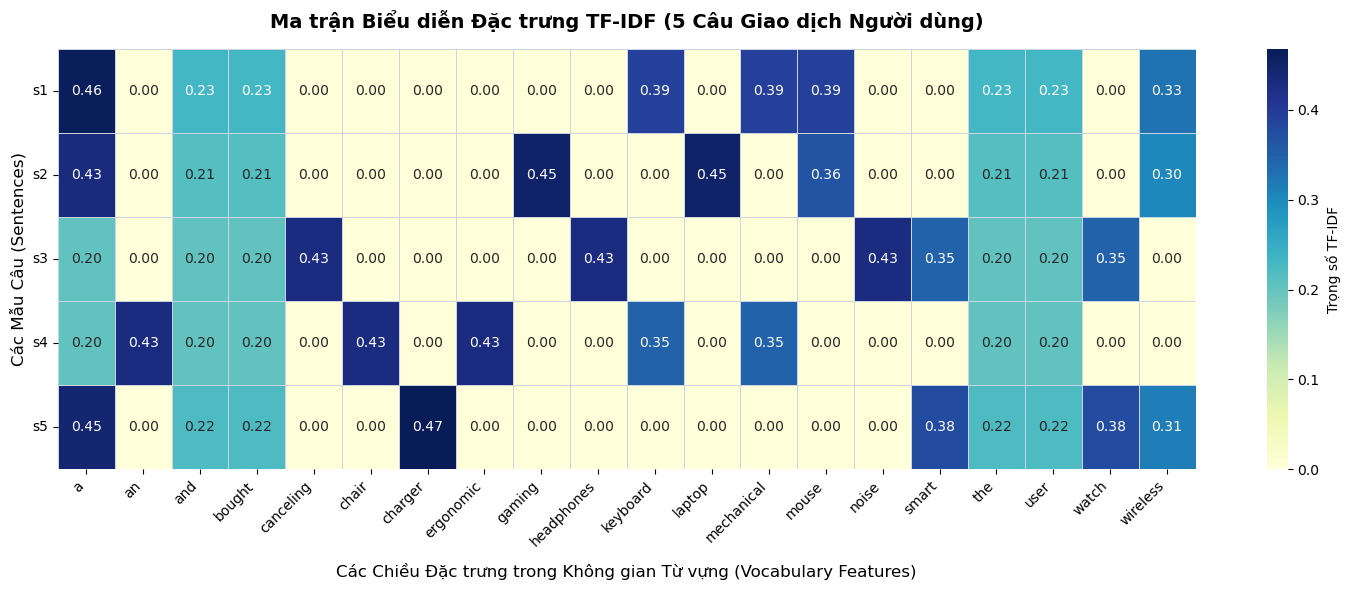

In [5]:
plt.figure(figsize=(15, 6))
sns.heatmap(
    df_tfidf,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Trọng số TF-IDF"},
    linewidths=0.5,
    linecolor="#cbd5e1"
)
plt.title("Ma trận Biểu diễn Đặc trưng TF-IDF (5 Câu Giao dịch Người dùng)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Các Chiều Đặc trưng trong Không gian Từ vựng (Vocabulary Features)", fontsize=12, labelpad=10)
plt.ylabel("Các Mẫu Câu (Sentences)", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

---
### 6. Đo lường Độ tương đồng Ngữ nghĩa (Cosine Similarity) giữa các Người dùng
Dựa trên ma trận biểu diễn $\mathbf{X} \in \mathbb{R}^{5 	imes d}$, ta tính ma trận độ tương đồng Cosine giữa các câu:
$$S_{i,j} = \cos(s_i, s_j) = rac{\mathbf{x}_i \cdot \mathbf{x}_j}{\|\mathbf{x}_i\|_2 \|\mathbf{x}_j\|_2}$$

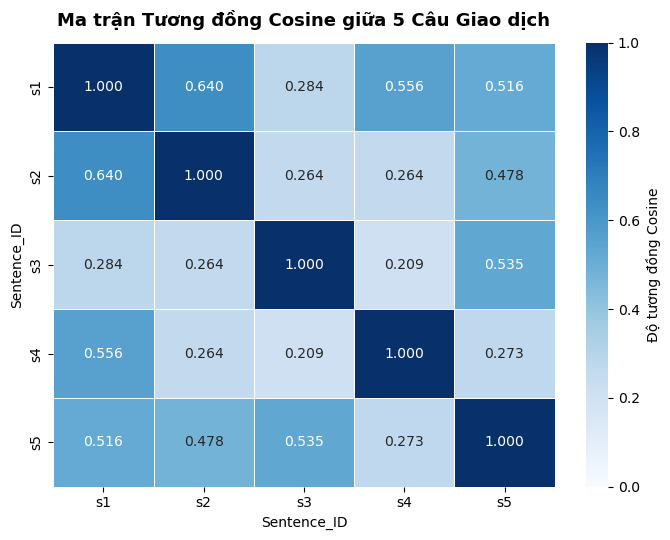


Phân tích tương đồng giao dịch:
1. s1 (Mouse + Keyboard) và s2 (Laptop + Mouse) có độ tương đồng cao do cùng mua 'wireless mouse'.
2. s1 (Mouse + Keyboard) và s4 (Keyboard + Chair) có độ tương đồng cao do cùng mua 'mechanical keyboard'.
3. s3 (Headphones + Smart watch) và s5 (Smart watch + Charger) có độ tương đồng do cùng mua 'smart watch'.


In [6]:
# Tính toán Cosine Similarity
cos_sim = cosine_similarity(tfidf_matrix)
df_sim = pd.DataFrame(cos_sim, index=df_corpus["Sentence_ID"], columns=df_corpus["Sentence_ID"])

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    df_sim,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Độ tương đồng Cosine"}
)
plt.title("Ma trận Tương đồng Cosine giữa 5 Câu Giao dịch", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("\nPhân tích tương đồng giao dịch:")
print("1. s1 (Mouse + Keyboard) và s2 (Laptop + Mouse) có độ tương đồng cao do cùng mua 'wireless mouse'.")
print("2. s1 (Mouse + Keyboard) và s4 (Keyboard + Chair) có độ tương đồng cao do cùng mua 'mechanical keyboard'.")
print("3. s3 (Headphones + Smart watch) và s5 (Smart watch + Charger) có độ tương đồng do cùng mua 'smart watch'.")